
# Техническое зрение для детекции зазоров электролизной ванны

Ноутбук предназначен для настройки алгоритма, который по RGB-изображению:

1. выделяет горизонтальные балки и зазоры;
2. сортирует зазоры по координате `v`;
3. ищет центральный визуальный репер;
4. присваивает зазорам номера пар;
5. выбирает ближайший необследованный зазор;
6. формирует визуальную цель;
7. передаёт управление одометрии перед исчезновением цели под капотом.

Координаты OpenCV: начало в левом верхнем углу, `u` растёт вправо, `v` — вниз. Поэтому ближайший видимый зазор обычно имеет максимальную координату `v`.


## 0. Зависимости

In [ ]:

# Выполнить при необходимости:
# %pip install opencv-python numpy scipy matplotlib pandas pyyaml ipywidgets


## 1. Импорты и структуры данных

In [1]:

from __future__ import annotations
from dataclasses import dataclass, asdict
from enum import Enum, auto
from pathlib import Path
from typing import Optional, Sequence
import json, math, time

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from scipy.signal import find_peaks


In [2]:

@dataclass
class VisionConfig:
    roi_x0: float = 0.05
    roi_x1: float = 0.95
    roi_y0: float = 0.05
    roi_y1: float = 0.95

    clahe_clip_limit: float = 2.0
    clahe_grid_size: int = 8
    gaussian_kernel: int = 9

    profile_channel: str = 'L'  # L, a, b, gray
    profile_quantile: float = 0.50

    min_peak_prominence: float = 3.0
    min_peak_distance_px: int = 8
    max_peak_count: int = 80

    min_interval_height_px: int = 4
    max_interval_height_px: int = 90

    gap_darkness_weight: float = 1.0
    gap_edge_weight: float = 0.5
    gap_texture_weight: float = 0.2
    gap_score_threshold: float = 0.0

    center_color_distance_threshold: float = 12.0
    center_min_confidence: float = 0.55

    desired_u_norm: float = 0.50
    handoff_v_norm: float = 0.78
    target_zone_half_width_px: int = 20
    target_zone_half_height_px: int = 12

    min_detection_confidence: float = 0.45

    pairs_left_of_center: tuple[int, ...] = (6, 5, 4, 3, 2, 1)
    pairs_right_of_center: tuple[int, ...] = (7, 8, 9, 10, 11, 12)


@dataclass
class HorizontalInterval:
    top: int
    bottom: int
    center_v: float
    height: int
    mean_lab: tuple[float, float, float]
    std_l: float
    edge_density: float
    texture: float
    gap_score: float
    label: str
    confidence: float


@dataclass
class GapDetection:
    center_u: float
    center_v: float
    top: int
    bottom: int
    confidence: float
    relative_index: Optional[int] = None
    pair_id: Optional[int] = None
    visited: bool = False


@dataclass
class CenterReference:
    detected: bool
    center_v: Optional[float]
    interval_indices: Optional[tuple[int, int]]
    confidence: float


@dataclass
class VisionResult:
    gaps: list[GapDetection]
    center_reference: CenterReference
    target: Optional[GapDetection]
    handoff_v: float
    target_reached_visual_line: bool
    debug_image: np.ndarray
    diagnostics: dict


## 2. Загрузка изображения

Найдено изображений: 40
Используется: /Users/kamiliskhakov/VS Code Project/RTK2026/records/experiments/electrolysis_20260727_120058/rgb_frames/frame_000210.png (480, 640, 3)


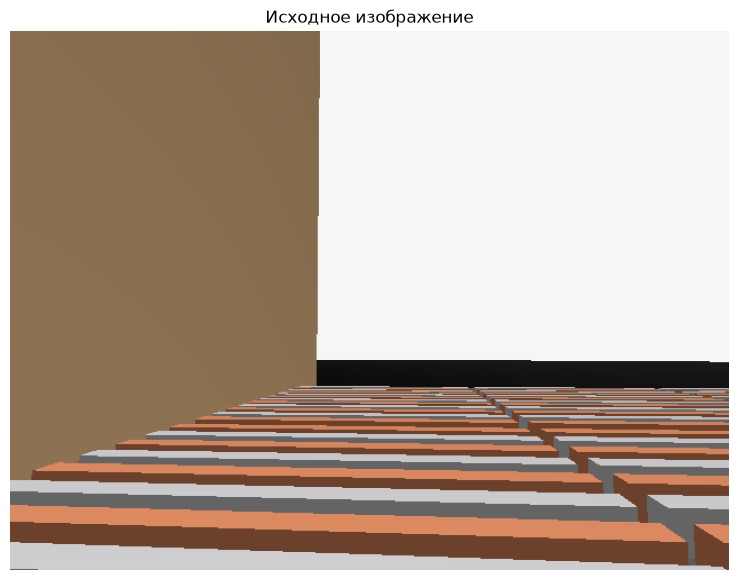

In [4]:

DATA_DIR = Path('/Users/kamiliskhakov/VS Code Project/RTK2026/records/experiments/electrolysis_20260727_120058/rgb_frames')

def list_candidate_images(root=DATA_DIR):
    exts={'.png','.jpg','.jpeg','.bmp','.webp'}
    return sorted(p for p in root.rglob('*') if p.is_file() and p.suffix.lower() in exts)

def load_bgr(path):
    img=cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)
    return img

def show_bgr(img, title='', figsize=(12,7)):
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

candidate_images=list_candidate_images()[210:250]
print('Найдено изображений:', len(candidate_images))
for p in candidate_images[210:250]: print(p)

IMAGE_PATH = candidate_images[0] if candidate_images else None
frame_bgr = load_bgr(IMAGE_PATH) if IMAGE_PATH else None
if frame_bgr is not None:
    print('Используется:', IMAGE_PATH, frame_bgr.shape)
    show_bgr(frame_bgr, 'Исходное изображение')


## 3. ROI и нормализация

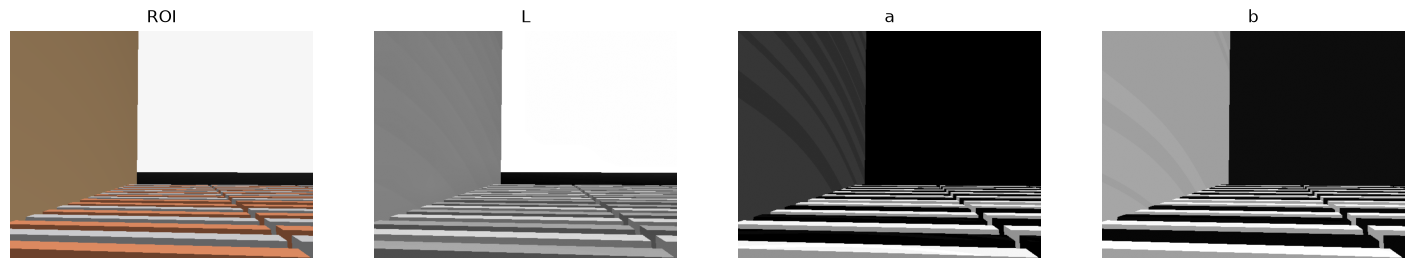

In [5]:

def crop_roi(image, cfg):
    h,w=image.shape[:2]
    x0=int(cfg.roi_x0*w); x1=int(cfg.roi_x1*w)
    y0=int(cfg.roi_y0*h); y1=int(cfg.roi_y1*h)
    if x1<=x0 or y1<=y0: raise ValueError('Некорректная ROI')
    return image[y0:y1, x0:x1].copy(), (x0,y0)

def normalize_image(image_bgr, cfg):
    lab=cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
    l,a,b=cv2.split(lab)
    clahe=cv2.createCLAHE(cfg.clahe_clip_limit,(cfg.clahe_grid_size,cfg.clahe_grid_size))
    l_eq=clahe.apply(l)
    lab_eq=cv2.merge([l_eq,a,b])
    bgr_eq=cv2.cvtColor(lab_eq, cv2.COLOR_LAB2BGR)
    gray=cv2.cvtColor(bgr_eq, cv2.COLOR_BGR2GRAY)
    return {'bgr':bgr_eq,'lab':lab_eq,'L':l_eq,'a':a,'b':b,'gray':gray}

cfg=VisionConfig()
if frame_bgr is not None:
    roi_bgr, roi_offset=crop_roi(frame_bgr,cfg)
    channels=normalize_image(roi_bgr,cfg)
    fig,ax=plt.subplots(1,4,figsize=(18,5))
    ax[0].imshow(cv2.cvtColor(roi_bgr,cv2.COLOR_BGR2RGB)); ax[0].set_title('ROI')
    for a,key in zip(ax[1:],['L','a','b']): a.imshow(channels[key],cmap='gray'); a.set_title(key)
    for a in ax: a.axis('off')
    plt.show()


## 4. Одномерный профиль

Так как балки горизонтальны, агрегируем изображение по ширине:

\[
p(v)=\operatorname{median}_{u} I(u,v).
\]


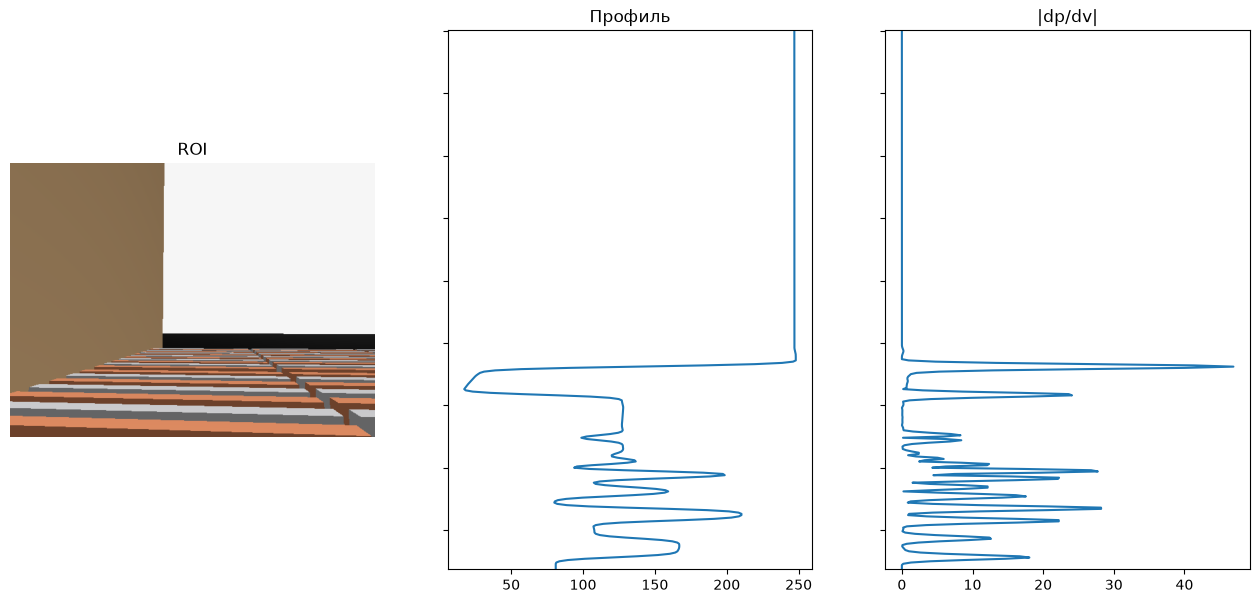

In [24]:

def robust_row_profile(channel, q=0.5):
    return np.quantile(channel.astype(np.float32),q,axis=1)

def smooth_profile(profile,kernel):
    kernel=max(3,int(kernel)); kernel += (kernel%2==0)
    return cv2.GaussianBlur(profile.reshape(-1,1).astype(np.float32),(1,kernel),0).ravel()

def compute_profiles(channels,cfg):
    source=channels.get(cfg.profile_channel,channels['a'])
    raw=robust_row_profile(source,cfg.profile_quantile)
    smooth=smooth_profile(raw,cfg.gaussian_kernel)
    gradient=np.abs(np.gradient(smooth))
    edges=cv2.Canny(channels['gray'],50,150).astype(np.float32)/255.0
    return {'raw':raw,'smooth':smooth,'gradient':gradient,
            'edge':edges.mean(axis=1),
            'texture':channels['gray'].astype(np.float32).std(axis=1)}

if frame_bgr is not None:
    profiles=compute_profiles(channels,cfg)
    y=np.arange(len(profiles['smooth']))
    fig,ax=plt.subplots(1,3,figsize=(16,7),sharey=True)
    ax[0].imshow(cv2.cvtColor(roi_bgr,cv2.COLOR_BGR2RGB)); ax[0].axis('off'); ax[0].set_title('ROI')
    ax[1].plot(profiles['smooth'],y); ax[1].invert_yaxis(); ax[1].set_title('Профиль')
    ax[2].plot(profiles['gradient'],y); ax[2].invert_yaxis(); ax[2].set_title('|dp/dv|')
    plt.show()


## 5. Границы и интервалы

,top,bottom,center_v,height,mean_lab,std_l,edge_density,texture,gap_score,label,confidence
0,269,292,280.5,23,"(66.58076690821257, 130.4501056763285, 137.029...",56.466922,0.027325,50.893303,0.252735,gap,0.883075
1,292,328,310.0,36,"(128.01977237654322, 137.5687210648148, 144.18...",39.817853,0.226273,39.460739,0.102305,gap,0.693906
2,328,353,340.5,25,"(130.1917361111111, 140.28520833333334, 145.39...",45.104891,0.204375,45.271557,0.087396,gap,0.668004
3,353,365,359.0,12,"(146.16290509259258, 132.38975694444446, 133.0...",52.145161,0.155382,53.206333,0.006491,gap,0.512979
4,365,373,369.0,8,"(135.64822048611111, 146.828125, 151.784288194...",34.184125,0.120443,33.811203,0.015044,gap,0.530051
5,373,383,378.0,10,"(116.18020833333334, 143.1472222222222, 147.35...",52.030752,0.111632,52.464859,0.101614,gap,0.692729
6,383,393,388.0,10,"(172.28315972222222, 131.1732638888889, 130.89...",56.468110,0.094097,57.492649,-0.123222,beam,0.728253
7,393,407,400.0,14,"(129.95200892857142, 132.33159722222223, 132.6...",38.802286,0.076885,39.723251,0.020240,gap,0.540391
8,407,422,414.5,15,"(146.3542824074074, 149.95833333333334, 156.03...",32.763226,0.063657,32.497044,-0.056364,beam,0.610857
9,422,431,426.5,9,"(103.45486111111111, 146.58159722222223, 152.1...",37.079071,0.057870,36.641903,0.112226,gap,0.710499


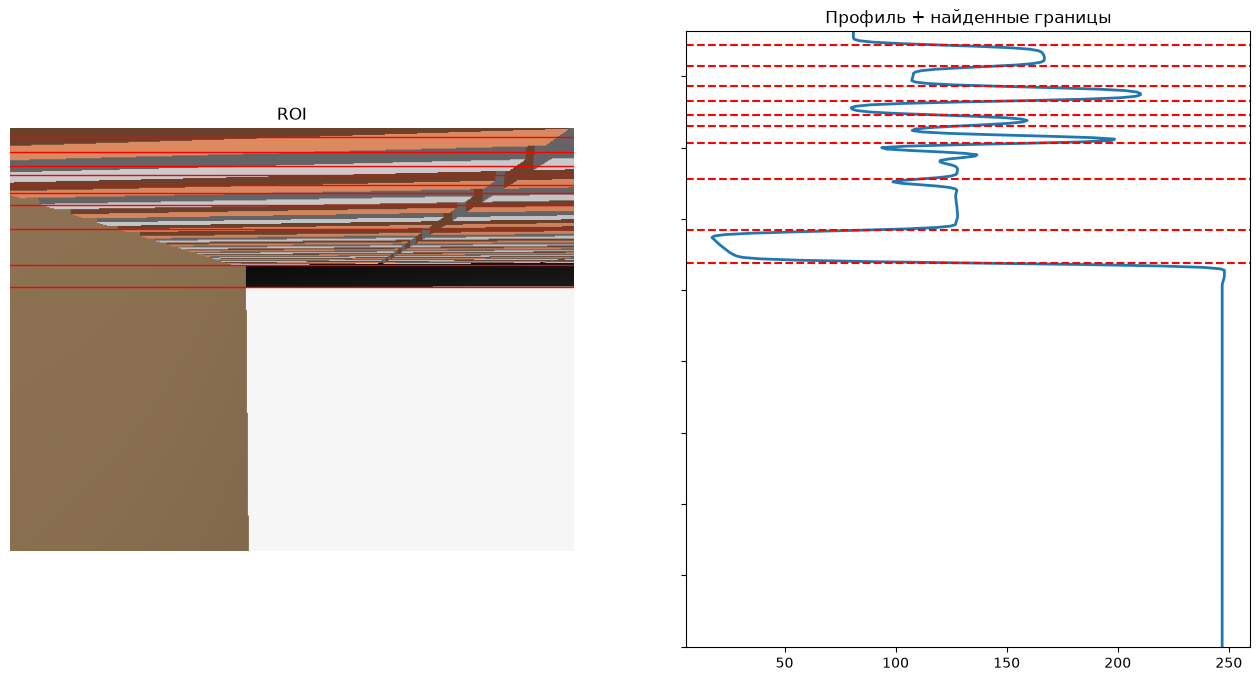

In [27]:

def detect_boundaries(gradient,cfg):
    prominence=max(cfg.min_peak_prominence,float(np.std(gradient)*0.75))
    peaks,props=find_peaks(gradient,prominence=prominence,distance=cfg.min_peak_distance_px)
    if len(peaks)>cfg.max_peak_count:
        keep=np.argsort(props['prominences'])[-cfg.max_peak_count:]
        peaks=np.sort(peaks[keep])
    return peaks.astype(int)

def interval_features(lab,gray,edge,top,bottom):
    p_lab=lab[top:bottom]; p_gray=gray[top:bottom]; p_edge=edge[top:bottom]
    mean_lab=p_lab.reshape(-1,3).mean(axis=0)
    return dict(mean_lab=tuple(float(x) for x in mean_lab),
                std_l=float(p_lab[:,:,0].std()),
                edge_density=float((p_edge>0).mean()),
                texture=float(p_gray.astype(np.float32).std()))

def build_intervals(channels,boundaries,cfg):
    h=channels['gray'].shape[0]
    edge=cv2.Canny(channels['gray'],50,150)
    bounds=np.unique(np.concatenate([[0],boundaries,[h-1]])).astype(int)
    global_l=float(np.median(channels['L']))
    global_t=float(np.median(channels['gray'].astype(np.float32).std(axis=1)))
    out=[]
    for top,bottom in zip(bounds[:-1],bounds[1:]):
        height=int(bottom-top)
        if not cfg.min_interval_height_px<=height<=cfg.max_interval_height_px: continue
        f=interval_features(channels['lab'],channels['gray'],edge,top,bottom)
        darkness=(global_l-f['mean_lab'][0])/255.0
        texture=(f['texture']-global_t)/255.0
        score=cfg.gap_darkness_weight*darkness+cfg.gap_edge_weight*f['edge_density']+cfg.gap_texture_weight*texture
        label='gap' if score>=cfg.gap_score_threshold else 'beam'
        conf=float(1/(1+np.exp(-8*abs(score-cfg.gap_score_threshold))))
        out.append(HorizontalInterval(top,bottom,(top+bottom)/2,height,f['mean_lab'],f['std_l'],f['edge_density'],f['texture'],float(score),label,conf))
    return out

if frame_bgr is not None:
    boundaries=detect_boundaries(profiles['gradient'],cfg)
    intervals=build_intervals(channels,boundaries,cfg)
    display(pd.DataFrame([asdict(x) for x in intervals]))
    debug = roi_bgr.copy()

for y in boundaries:
    cv2.line(
        debug,
        (0, int(y)),
        (debug.shape[1]-1, int(y)),
        (0, 0, 255),
        2,
    )

fig, ax = plt.subplots(
    1,
    2,
    figsize=(16,8),
    sharey=True,
)

# изображение
ax[0].imshow(cv2.cvtColor(roi_bgr,cv2.COLOR_BGR2RGB))
ax[0].axis("off")
ax[0].set_title("ROI")

for y in boundaries:
    ax[0].axhline(
        y,
        color="red",
        linewidth=1,
    )

# профиль
y=np.arange(len(profiles["smooth"]))

ax[1].plot(
    profiles["smooth"],
    y,
    linewidth=2,
)

ax[1].invert_yaxis()

for y in boundaries:
    ax[1].axhline(
        y,
        color="red",
        linestyle="--",
    )

ax[1].set_title("Профиль + найденные границы")

plt.show()

## 6. Центральный репер

In [17]:

def chroma_distance(c1,c2):
    return float(math.hypot(c1[1]-c2[1],c1[2]-c2[2]))

def detect_center_reference(intervals,cfg):
    cand=[]
    for i in range(len(intervals)-1):
        a,b=intervals[i],intervals[i+1]
        if a.label!='beam' or b.label!='beam': continue
        d=chroma_distance(a.mean_lab,b.mean_lab)
        color=math.exp(-d/max(cfg.center_color_distance_threshold,1e-6))
        width=1-min(1,abs(a.height-b.height)/max(a.height,b.height,1))
        neigh=intervals[max(0,i-3):min(len(intervals),i+5)]
        gap_frac=sum(x.label=='gap' for x in neigh)/max(len(neigh),1)
        conf=.55*color+.25*width+.20*min(1,gap_frac*2)
        cand.append((conf,i,i+1))
    if not cand: return CenterReference(False,None,None,0.0)
    conf,i,j=max(cand,key=lambda x:x[0])
    if conf<cfg.center_min_confidence: return CenterReference(False,None,None,float(conf))
    return CenterReference(True,float((intervals[i].center_v+intervals[j].center_v)/2),(i,j),float(conf))

if frame_bgr is not None:
    center_ref=detect_center_reference(intervals,cfg)
    print(center_ref)


CenterReference(detected=False, center_v=None, interval_indices=None, confidence=0.0)


## 7. Зазоры и номера пар

In [18]:

def intervals_to_gaps(intervals,image_width,cfg):
    gaps=[]
    for x in intervals:
        if x.label=='gap' and x.confidence>=cfg.min_detection_confidence:
            gaps.append(GapDetection(image_width/2,x.center_v,x.top,x.bottom,x.confidence))
    return sorted(gaps,key=lambda g:g.center_v)

def assign_pair_ids(gaps,center,cfg):
    if not center.detected or center.center_v is None: return gaps
    above=sorted([g for g in gaps if g.center_v<center.center_v],key=lambda g:abs(g.center_v-center.center_v))
    below=sorted([g for g in gaps if g.center_v>center.center_v],key=lambda g:abs(g.center_v-center.center_v))
    for i,g in enumerate(above):
        g.relative_index=-(i+1)
        if i<len(cfg.pairs_left_of_center): g.pair_id=cfg.pairs_left_of_center[i]
    for i,g in enumerate(below):
        g.relative_index=i+1
        if i<len(cfg.pairs_right_of_center): g.pair_id=cfg.pairs_right_of_center[i]
    return sorted(gaps,key=lambda g:g.center_v)

if frame_bgr is not None:
    gaps=assign_pair_ids(intervals_to_gaps(intervals,roi_bgr.shape[1],cfg),center_ref,cfg)
    display(pd.DataFrame([asdict(g) for g in gaps]))


,center_u,center_v,top,bottom,confidence,relative_index,pair_id,visited
0,288.0,280.5,269,292,0.883075,None,None,False
1,288.0,310.0,292,328,0.693906,None,None,False
2,288.0,340.5,328,353,0.668004,None,None,False
3,288.0,359.0,353,365,0.512979,None,None,False
4,288.0,369.0,365,373,0.530051,None,None,False
5,288.0,378.0,373,383,0.692729,None,None,False
6,288.0,400.0,393,407,0.540391,None,None,False
7,288.0,426.5,422,431,0.710499,None,None,False


## 8. Выбор цели и handoff-line

In [10]:

def choose_target(gaps,visited_pairs):
    cand=[g for g in gaps if g.pair_id is not None and g.pair_id not in visited_pairs]
    return max(cand,key=lambda g:g.center_v) if cand else None

def target_geometry(target,image_shape,cfg):
    h,w=image_shape
    desired_u=cfg.desired_u_norm*w
    handoff_v=cfg.handoff_v_norm*h
    if target is None:
        return dict(desired_u=desired_u,handoff_v=handoff_v,error_u=None,error_v=None,crossed=False)
    return dict(desired_u=desired_u,handoff_v=handoff_v,
                error_u=target.center_u-desired_u,
                error_v=handoff_v-target.center_v,
                crossed=target.center_v>=handoff_v)

visited_pairs=set()
if frame_bgr is not None:
    target=choose_target(gaps,visited_pairs)
    print(target)
    print(target_geometry(target,roi_bgr.shape[:2],cfg))


None
{'desired_u': 288.0, 'handoff_v': 336.96000000000004, 'error_u': None, 'error_v': None, 'crossed': False}


## 9. Debug overlay

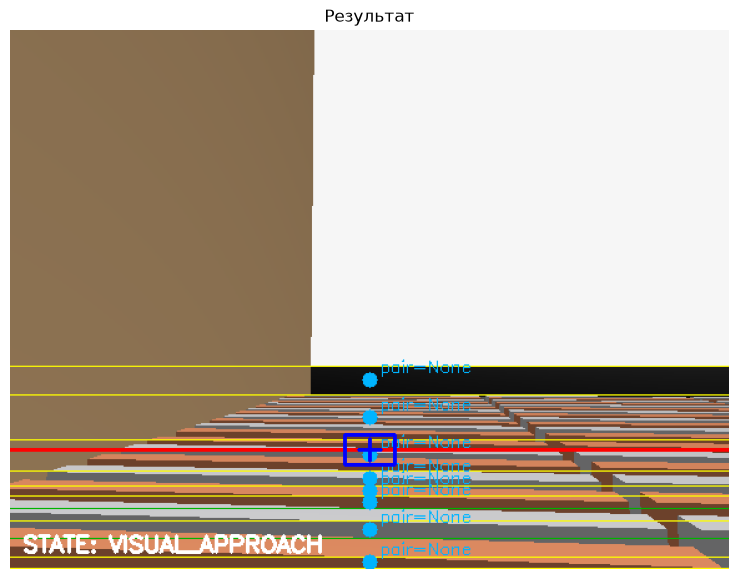

In [11]:

def draw_overlay(image,intervals,gaps,center,target,cfg,state='DETECT'):
    out=image.copy(); h,w=out.shape[:2]
    for x in intervals:
        color=(0,255,255) if x.label=='gap' else (0,180,0)
        cv2.line(out,(0,x.top),(w-1,x.top),color,1)
        cv2.line(out,(0,x.bottom),(w-1,x.bottom),color,1)
    if center.detected and center.center_v is not None:
        y=int(center.center_v); cv2.line(out,(0,y),(w-1,y),(255,0,255),3)
        cv2.putText(out,f'CENTER {center.confidence:.2f}',(10,max(20,y-8)),cv2.FONT_HERSHEY_SIMPLEX,.55,(255,0,255),2)
    for g in gaps:
        p=(int(g.center_u),int(g.center_v)); cv2.circle(out,p,6,(255,180,0),-1)
        cv2.putText(out,f'pair={g.pair_id}',(p[0]+8,max(18,p[1]-6)),cv2.FONT_HERSHEY_SIMPLEX,.45,(255,180,0),1)
    handoff=int(cfg.handoff_v_norm*h); desired=int(cfg.desired_u_norm*w)
    cv2.line(out,(0,handoff),(w-1,handoff),(0,0,255),2)
    cv2.rectangle(out,(desired-cfg.target_zone_half_width_px,handoff-cfg.target_zone_half_height_px),(desired+cfg.target_zone_half_width_px,handoff+cfg.target_zone_half_height_px),(255,0,0),2)
    cv2.drawMarker(out,(desired,handoff),(255,0,0),cv2.MARKER_CROSS,18,2)
    if target is not None:
        p=(int(target.center_u),int(target.center_v)); cv2.circle(out,p,11,(0,0,255),3)
        cv2.arrowedLine(out,p,(desired,handoff),(0,0,255),2,tipLength=.08)
        cv2.putText(out,f'TARGET pair={target.pair_id}',(10,28),cv2.FONT_HERSHEY_SIMPLEX,.72,(0,0,255),2)
    cv2.putText(out,f'STATE: {state}',(10,h-14),cv2.FONT_HERSHEY_SIMPLEX,.6,(255,255,255),2)
    return out

if frame_bgr is not None:
    overlay=draw_overlay(roi_bgr,intervals,gaps,center_ref,target,cfg,'VISUAL_APPROACH')
    show_bgr(overlay,'Результат')


## 10. Полная функция `process_frame`

{
  "roi_offset": [
    32,
    24
  ],
  "num_boundaries": 10,
  "num_intervals": 10,
  "num_gaps": 8,
  "center_detected": false,
  "center_confidence": 0.0,
  "target_pair_id": null,
  "target_confidence": null,
  "error_u": null,
  "error_v": null
}


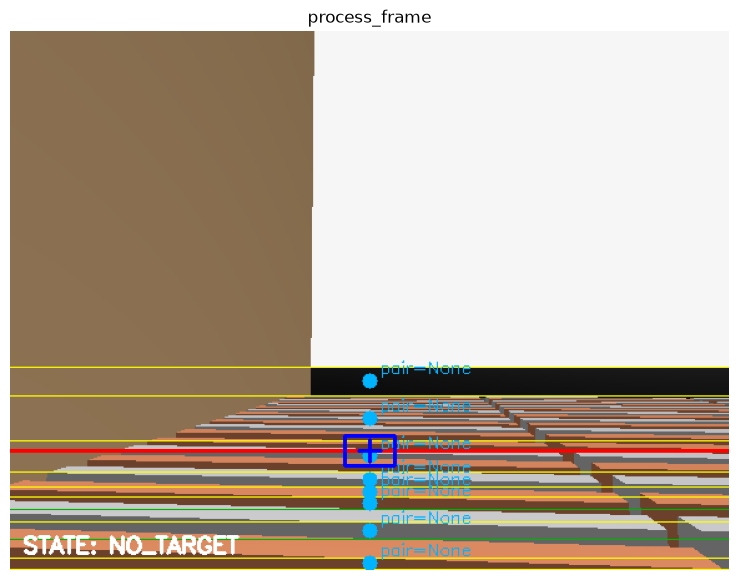

In [12]:

def process_frame(frame,cfg,visited_pairs=None):
    visited_pairs=set() if visited_pairs is None else visited_pairs
    roi,offset=crop_roi(frame,cfg)
    ch=normalize_image(roi,cfg)
    pr=compute_profiles(ch,cfg)
    bounds=detect_boundaries(pr['gradient'],cfg)
    intervals=build_intervals(ch,bounds,cfg)
    center=detect_center_reference(intervals,cfg)
    gaps=assign_pair_ids(intervals_to_gaps(intervals,roi.shape[1],cfg),center,cfg)
    for g in gaps: g.visited=(g.pair_id in visited_pairs) if g.pair_id is not None else False
    target=choose_target(gaps,visited_pairs)
    geom=target_geometry(target,roi.shape[:2],cfg)
    debug=draw_overlay(roi,intervals,gaps,center,target,cfg,'VISUAL_APPROACH' if target else 'NO_TARGET')
    diag=dict(roi_offset=offset,num_boundaries=len(bounds),num_intervals=len(intervals),num_gaps=len(gaps),
              center_detected=center.detected,center_confidence=center.confidence,
              target_pair_id=None if target is None else target.pair_id,
              target_confidence=None if target is None else target.confidence,
              error_u=geom['error_u'],error_v=geom['error_v'])
    return VisionResult(gaps,center,target,float(geom['handoff_v']),bool(geom['crossed']),debug,diag)

if frame_bgr is not None:
    result=process_frame(frame_bgr,cfg)
    print(json.dumps(result.diagnostics,indent=2,ensure_ascii=False))
    show_bgr(result.debug_image,'process_frame')


## 11. Visual servoing и конечный автомат

In [13]:

class ScanState(Enum):
    DETECT_REFERENCE=auto(); SELECT_TARGET=auto(); VISUAL_APPROACH=auto()
    ODOMETRY_APPROACH=auto(); SETTLE=auto(); MEASURE_FIELD=auto()
    RELEASE_TARGET=auto(); FINISHED=auto()

@dataclass
class MotionCommand:
    linear_x: float
    angular_z: float
    stop: bool
    reason: str

def clamp(x,a,b): return max(a,min(b,x))

def compute_visual_servo_command(result,image_shape,cfg,k_u=.0025,k_v=.0015,max_linear=.10,max_angular=.45):
    t=result.target
    if t is None: return MotionCommand(0,0,True,'target_not_visible')
    h,w=image_shape
    e_u=t.center_u-cfg.desired_u_norm*w
    e_v=result.handoff_v-t.center_v
    omega=clamp(-k_u*e_u,-max_angular,max_angular)
    if result.target_reached_visual_line:
        return MotionCommand(0,0,True,'handoff_reached')
    v=clamp(k_v*max(e_v,0),.015,max_linear)
    if abs(e_u)>.15*w: v=min(v,.025)
    return MotionCommand(v,omega,False,'visual_approach')

if frame_bgr is not None:
    print(compute_visual_servo_command(result,result.debug_image.shape[:2],cfg))


MotionCommand(linear_x=0, angular_z=0, stop=True, reason='target_not_visible')


## 12. Обработка видео

In [14]:

def process_video(input_path,output_path,cfg,max_frames=None):
    cap=cv2.VideoCapture(str(input_path))
    if not cap.isOpened(): raise FileNotFoundError(input_path)
    fps=cap.get(cv2.CAP_PROP_FPS) or 20.0
    w=int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)); h=int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    out_w=int((cfg.roi_x1-cfg.roi_x0)*w); out_h=int((cfg.roi_y1-cfg.roi_y0)*h)
    writer=cv2.VideoWriter(str(output_path),cv2.VideoWriter_fourcc(*'mp4v'),fps,(out_w,out_h))
    rows=[]; frame_id=0
    try:
        while True:
            ok,frame=cap.read()
            if not ok: break
            result=process_frame(frame,cfg)
            writer.write(result.debug_image)
            rows.append({'frame_id':frame_id,'time_s':frame_id/fps,**result.diagnostics,'handoff':result.target_reached_visual_line})
            frame_id+=1
            if max_frames is not None and frame_id>=max_frames: break
    finally:
        cap.release(); writer.release()
    return pd.DataFrame(rows)

# Пример:
# stats=process_video('/mnt/data/input.mp4','/mnt/data/vision_debug.mp4',cfg)
# display(stats.head())


## 13. Интерактивная настройка

In [15]:

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    def interactive_tuner(frame,base_cfg):
        prominence=widgets.FloatSlider(value=base_cfg.min_peak_prominence,min=.1,max=30,step=.1,description='prominence',continuous_update=False)
        distance=widgets.IntSlider(value=base_cfg.min_peak_distance_px,min=2,max=80,description='peak dist',continuous_update=False)
        gap_thr=widgets.FloatSlider(value=base_cfg.gap_score_threshold,min=-.5,max=.5,step=.005,description='gap thr',continuous_update=False)
        handoff=widgets.FloatSlider(value=base_cfg.handoff_v_norm,min=.4,max=.95,step=.01,description='handoff',continuous_update=False)
        output=widgets.Output()
        def redraw(*_):
            local=VisionConfig(**asdict(base_cfg))
            local.min_peak_prominence=prominence.value; local.min_peak_distance_px=distance.value
            local.gap_score_threshold=gap_thr.value; local.handoff_v_norm=handoff.value
            with output:
                clear_output(wait=True)
                try:
                    r=process_frame(frame,local); show_bgr(r.debug_image,'Настройка'); print(json.dumps(r.diagnostics,indent=2,ensure_ascii=False))
                except Exception as e: print(type(e).__name__,e)
        for w in [prominence,distance,gap_thr,handoff]: w.observe(redraw,names='value')
        display(widgets.HBox([widgets.VBox([prominence,distance,gap_thr,handoff]),output])); redraw()

    if frame_bgr is not None: interactive_tuner(frame_bgr,cfg)
except ImportError:
    print('Установите ipywidgets')


## 14. Экспорт параметров

In [ ]:

def save_config_yaml(cfg,path='/mnt/data/gap_vision_config.yaml'):
    data=asdict(cfg)
    for k,v in list(data.items()):
        if isinstance(v,tuple): data[k]=list(v)
    with open(path,'w',encoding='utf-8') as f:
        yaml.safe_dump(data,f,allow_unicode=True,sort_keys=False)
    return Path(path)

config_path=save_config_yaml(cfg)
print(config_path)
print(config_path.read_text(encoding='utf-8'))


## 15. Что измерять на реальных данных

Оценивать следует не только кадры, а физические пары:

- доля правильно пронумерованных пар;
- доля пропущенных пар;
- доля повторно обработанных пар;
- ошибка момента handoff;
- задержка обработки;
- устойчивость к pitch/roll, теням и бликам;
- работа при движении в обоих направлениях.

Если классический алгоритм нестабилен только на этапе выделения поверхностей, нейросеть следует использовать как модуль `RGB -> mask(beam/gap)`, оставив нумерацию, handoff и управление детерминированными.
